In [1]:
# !pip install albumentations opencv-python

In [2]:
# !pip install timm torch torchvision

In [3]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import albumentations as A

from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
TRAIN_PATH = "../../dataset/removed/train"
TEST_PATH = "../../dataset/removed/test"
SUBMISSION_PATH = "../../samplesubmission.csv"

In [6]:
classes = [
    "fake_mannequin",
    "fake_mask",
    "fake_printed",
    "fake_screen",
    "fake_unknown",
    "realperson"
]

label2id = {c:i for i,c in enumerate(classes)}
id2label = {i:c for c,i in label2id.items()}

In [7]:
data = []

for label in classes:
    folder = os.path.join(TRAIN_PATH, label)

    for img in os.listdir(folder):
        data.append({
            "path": os.path.join(folder, img),
            "label": label2id[label]
        })

train_df = pd.DataFrame(data)

print("Total training images:", len(train_df))
train_df.head()

Total training images: 1454


,path,label
0,../../dataset/removed/train\fake_mannequin\man...,0
1,../../dataset/removed/train\fake_mannequin\man...,0
2,../../dataset/removed/train\fake_mannequin\man...,0
3,../../dataset/removed/train\fake_mannequin\man...,0
4,../../dataset/removed/train\fake_mannequin\man...,0


In [8]:
train_tfms = A.Compose([
    A.RandomResizedCrop(size=(224,224), scale=(0.8,1.0)),

    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),

    A.RandomBrightnessContrast(p=0.4),
    A.ColorJitter(p=0.3),

    A.GaussNoise(p=0.2),
])

test_tfms = A.Compose([
    A.Resize(224,224)
])

In [9]:
class FaceDataset(Dataset):

    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)["image"]

        img = img.astype(np.float32) / 255.0

        img = (img - np.array([0.485,0.456,0.406], dtype=np.float32)) / \
              np.array([0.229,0.224,0.225], dtype=np.float32)

        img = np.transpose(img,(2,0,1))

        label = int(row.label)  

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)

In [10]:
train_dataset = FaceDataset(train_df, train_tfms)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

In [11]:
model = timm.create_model(
    "convnext_small.fb_in22k_ft_in1k",
    pretrained=True,
    num_classes=6
)

model = model.to(device)

print("Model loaded")

Model loaded


In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [13]:
def train_one_epoch(loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total

    return total_loss / len(loader), acc

In [14]:
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {train_acc:.4f}"
    )

100%|██████████| 46/46 [10:37<00:00, 13.86s/it]


Epoch 1/10 | Loss: 1.0072 | Accuracy: 0.7235


100%|██████████| 46/46 [10:57<00:00, 14.30s/it]


Epoch 2/10 | Loss: 0.6155 | Accuracy: 0.9285


100%|██████████| 46/46 [10:13<00:00, 13.34s/it]


...

Epoch 8/10 | Loss: 0.4764 | Accuracy: 0.9766


100%|██████████| 46/46 [10:13<00:00, 13.34s/it]


Epoch 9/10 | Loss: 0.4687 | Accuracy: 0.9759


100%|██████████| 46/46 [10:02<00:00, 13.09s/it]

Epoch 10/10 | Loss: 0.4698 | Accuracy: 0.9807


In [15]:
torch.save(model.state_dict(), "convnext_final.pth")

print("Model saved.")

Model saved.


In [16]:
submission_df = pd.read_csv(SUBMISSION_PATH)

In [17]:
test_paths = []

for img_id in submission_df["id"]:

    found = False

    for ext in [".jpg", ".jpeg", ".png"]:

        img_path = os.path.join(TEST_PATH, img_id + ext)

        if os.path.exists(img_path):
            test_paths.append(img_path)
            found = True
            break

    if not found:
        print("Missing:", img_id)

test_df = pd.DataFrame({
    "path": test_paths
})

In [18]:
class TestDataset(Dataset):

    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        path = self.df.iloc[idx].path

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)["image"]

        img = img.astype(np.float32) / 255.0

        img = (img - np.array([0.485,0.456,0.406], dtype=np.float32)) / \
            np.array([0.229,0.224,0.225], dtype=np.float32)

        img = np.transpose(img,(2,0,1))

        return torch.tensor(img, dtype=torch.float32)

In [19]:
test_dataset = TestDataset(test_df, test_tfms)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [20]:
model.eval()

predictions = []

with torch.no_grad():

    for imgs in tqdm(test_loader):

        imgs = imgs.to(device)

        outputs = model(imgs)

        preds = outputs.argmax(1).cpu().numpy()

        predictions.extend(preds)

100%|██████████| 13/13 [01:05<00:00,  5.07s/it]


In [21]:
submission_df["label"] = [id2label[p] for p in predictions]

submission_df.to_csv("submission_convnext.csv", index=False)

print("Submission saved.")

Submission saved.


In [22]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [23]:
pred_df = pd.read_csv("submission_convnext.csv")
anot_df = pd.read_csv("../../samplesubmission_anotated_final.csv", sep=";")

print("Prediction shape:", pred_df.shape)
print("Anotated:", anot_df.shape)

pred_df.head()

Prediction shape: (404, 2)
Anotated: (404, 2)


,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


In [24]:
df = anot_df.merge(pred_df, on="id", suffixes=("_anot", "_pred"))

df.head()

,id,label_anot,label_pred
0,test_001,fake_screen,fake_screen
1,test_002,fake_mannequin,fake_mannequin
2,test_003,realperson,realperson
3,test_004,realperson,realperson
4,test_005,fake_screen,fake_printed


In [26]:
df["y_true"] = df["label_anot"].map(label2id)
df["y_pred"] = df["label_pred"].map(label2id)

In [27]:
macro_f1 = f1_score(df["y_true"], df["y_pred"], average="macro")

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.9287871172457304


In [28]:
print(classification_report(
    df["y_true"],
    df["y_pred"],
    target_names=classes
))

                precision    recall  f1-score   support

fake_mannequin       0.92      1.00      0.96        47
     fake_mask       0.89      0.95      0.92        66
  fake_printed       0.88      0.88      0.88        60
   fake_screen       0.96      0.89      0.92        74
  fake_unknown       0.98      0.92      0.95        50
    realperson       0.94      0.93      0.94       107

      accuracy                           0.93       404
     macro avg       0.93      0.93      0.93       404
  weighted avg       0.93      0.93      0.93       404



In [29]:
cm = confusion_matrix(df["y_true"], df["y_pred"])

cm

array([[ 47,   0,   0,   0,   0,   0],
       [  0,  63,   1,   0,   0,   2],
       [  1,   3,  53,   1,   0,   2],
       [  0,   1,   4,  66,   1,   2],
       [  2,   0,   1,   1,  46,   0],
       [  1,   4,   1,   1,   0, 100]], dtype=int64)

Text(0.5, 1.0, 'Confusion Matrix')

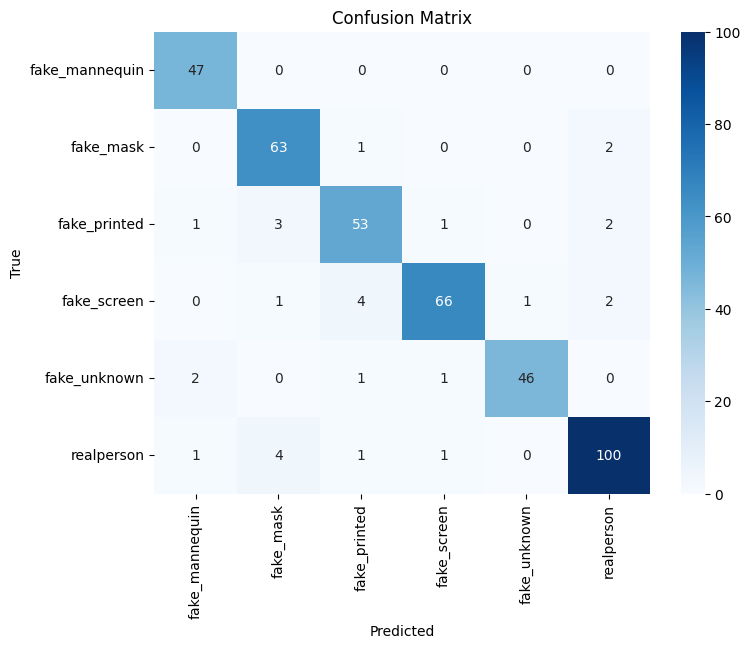

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")


In [32]:
print(df.columns)

Index(['id', 'label_anot', 'label_pred', 'y_true', 'y_pred'], dtype='object')


Total mistakes: 29


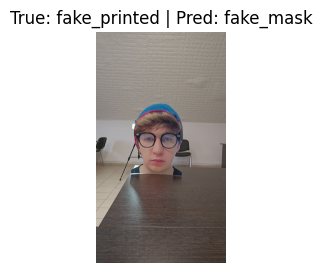

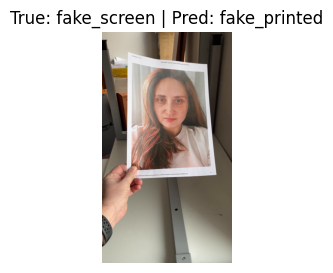

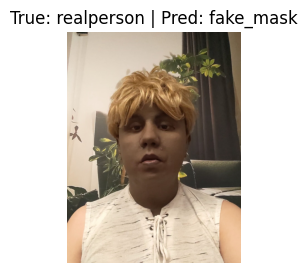

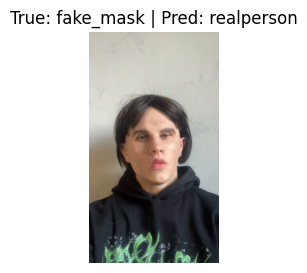

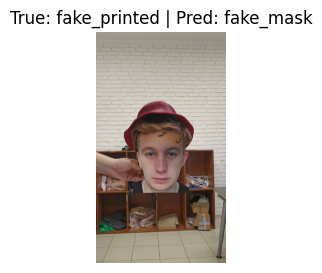

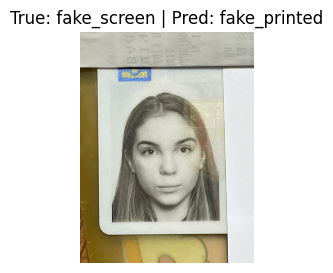

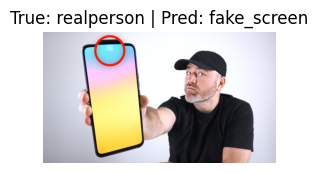

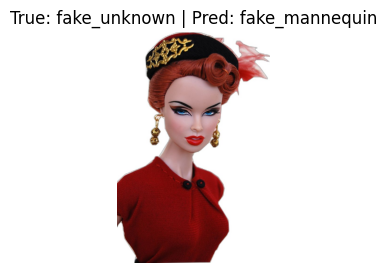

In [ ]:
mistakes = df[df["label_anot"] != df["label_pred"]]

print("Total mistakes:", len(mistakes))

sample = mistakes.sample(min(8, len(mistakes)))

for i, row in sample.iterrows():

    img_id = row["id"]
    path = os.path.join(TEST_PATH, img_id + ".jpg")

    img = cv2.imread(path)
    
    if img is None:
        print(f"Image not found: {path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"True: {row['label_anot']} | Pred: {row['label_pred']}")
    plt.axis("off")

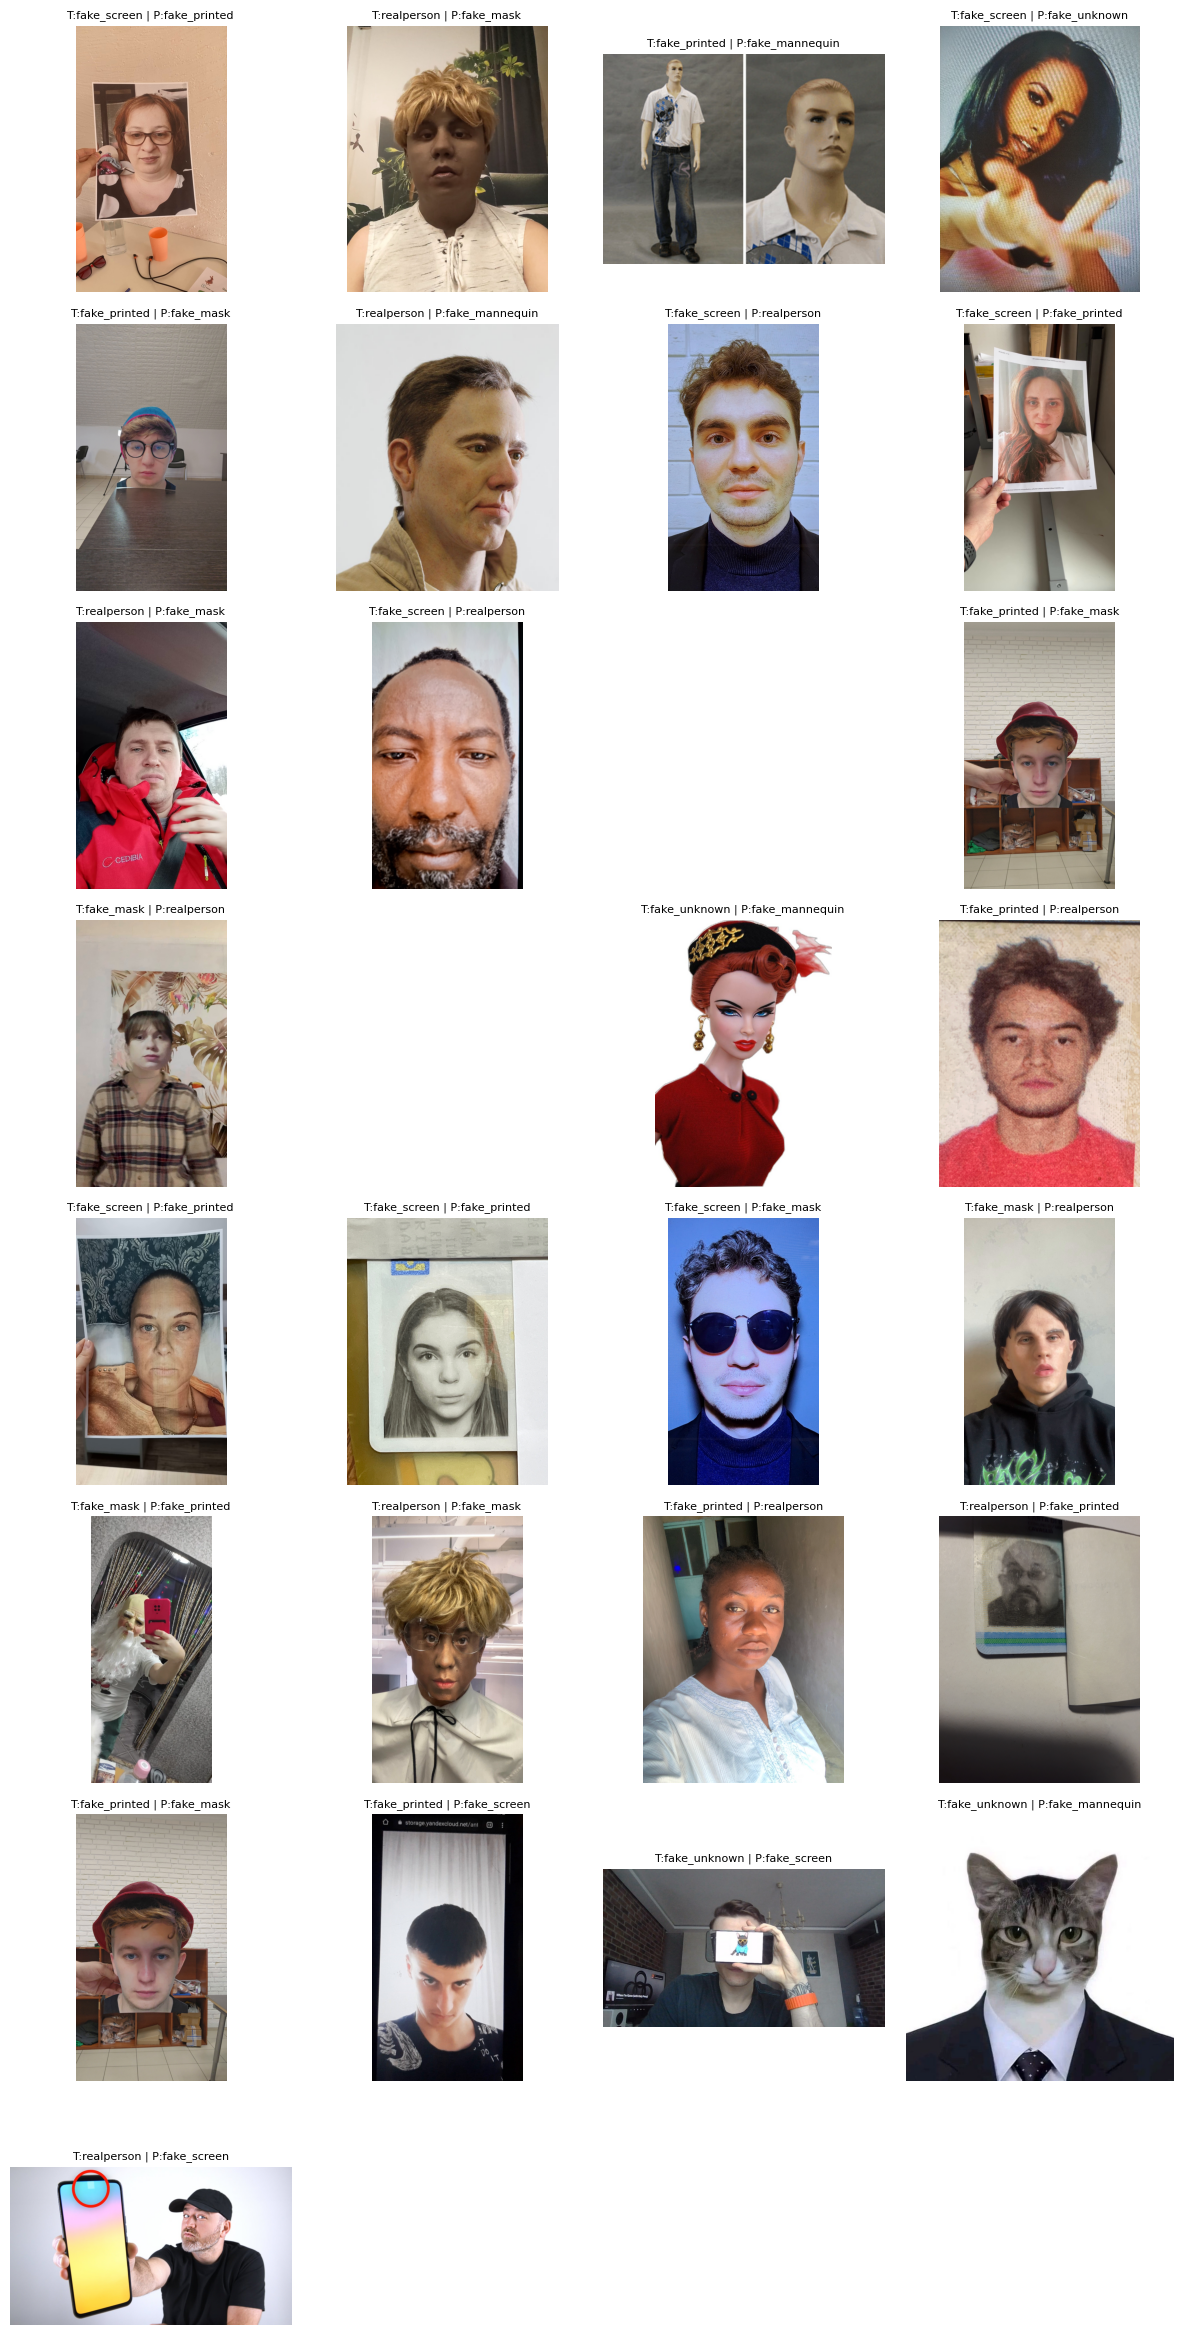

In [34]:
cols = 4
rows = int(np.ceil(len(mistakes) / cols))

plt.figure(figsize=(12, rows * 3))

for idx, (_, row) in enumerate(mistakes.iterrows()):

    img_id = row["id"]
    path = os.path.join(TEST_PATH, img_id + ".jpg")

    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(f"T:{row['label_anot']} | P:{row['label_pred']}", fontsize=8)
    plt.axis("off")

plt.tight_layout()